In [9]:
# Hide warnings
import warnings
warnings.filterwarnings('ignore')


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.feature_selection import SelectKBest, f_classif

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as Pipeline

import joblib


In [11]:
# Load dataset
df = pd.read_csv('Dataset/enhanced_dataset_final.csv')

# Explore dataset
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (736, 173)


,Body_Pain,Burning_Sensation,Itching,Excessive_Hunger,Frequent_Urination,Eye_Problems,Joint_Pain,Numbness,Weight_Gain,Weight_Loss,...,Constipation,Pulse_Rate_Decrease,Continuous_Sneezing,Cold.1,Blood_Clot,Pus_Filled_Pimple,Rashes,Mental_Anxiety,White_Spots_on_Mouth,Prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
4,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection


In [12]:
# Basic info
df.info()

# Target distribution
df['Prognosis'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Columns: 173 entries, Body_Pain to Prognosis
dtypes: int64(172), object(1)
memory usage: 994.9+ KB


Prognosis
Dengue                                   41
Diabetes                                 26
Dysentery                                22
Conjunctivitis                           18
Cancer                                   16
                                         ..
CCHFV Crimean Congo Hemorrhagic Fever     1
Paralysis Brain Hemorrhage                1
Dimorphic Hemorrhoids Piles               1
Vertigo Paroxysmal Positional Vertigo     1
COVID 19                                  1
Name: count, Length: 90, dtype: int64

No missing values found in the dataset.


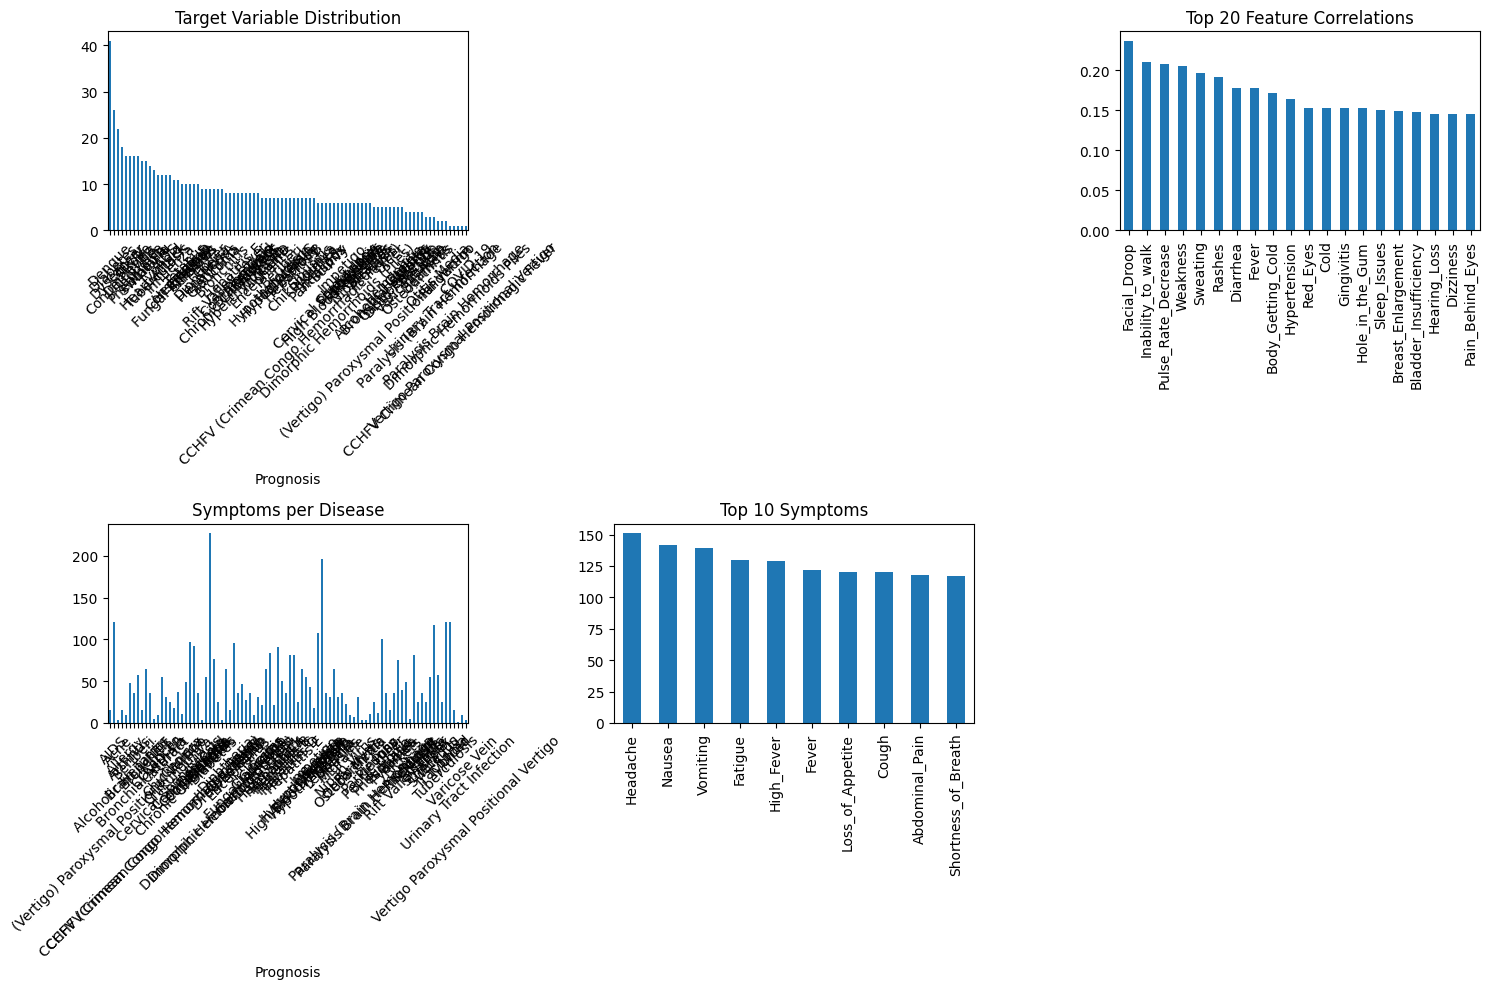

In [13]:
plt.figure(figsize=(15,10))
# Missing values
missing_values = df.isnull().sum()
missing_values_nonzero = missing_values[missing_values > 0]

if not missing_values_nonzero.empty:
    missing_values_nonzero.plot(kind='bar')
    plt.title('Missing Values')
else:
    print("No missing values found in the dataset.")

# Target distribution
plt.subplot(2,3,1)
df['Prognosis'].value_counts().plot(kind='bar')
plt.title('Target Variable Distribution')
plt.xticks(rotation=45)



# Feature correlation with target
plt.subplot(2,3,3)
le = LabelEncoder()
y_encoded = le.fit_transform(df['Prognosis'])
correlations = df.drop('Prognosis', axis=1).apply(lambda x: np.corrcoef(x, y_encoded)[0,1])
top_features = correlations.abs().nlargest(20)
top_features.plot(kind='bar')
plt.title('Top 20 Feature Correlations')

# Symptoms per disease
plt.subplot(2,3,4)
symptoms_per_disease = df.groupby('Prognosis').sum().sum(axis=1)
symptoms_per_disease.plot(kind='bar')
plt.title('Symptoms per Disease')
plt.xticks(rotation=45)

# Most common symptoms
plt.subplot(2,3,5)
common_symptoms = df.drop('Prognosis', axis=1).sum().nlargest(10)
common_symptoms.plot(kind='bar')
plt.title('Top 10 Symptoms')

plt.tight_layout()
plt.show()


In [14]:
# Features and target
X = df.drop('Prognosis', axis=1)
y = df['Prognosis']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# # Remove constant features
# constant_features = [col for col in X.columns if X[col].nunique() == 1]
# if constant_features:
#     X = X.drop(columns=constant_features)


In [15]:
# # Using SelectKBest
# selector = SelectKBest(score_func=f_classif, k=50)
# X_selected = selector.fit_transform(X, y_encoded)
# selected_features = X.columns[selector.get_support()]

# # Using RandomForest importance
# rf = RandomForestClassifier(n_estimators=100, random_state=42)
# rf.fit(X, y_encoded)
# feature_importances = pd.DataFrame({
#     'feature': X.columns,
#     'importance': rf.feature_importances_
# }).sort_values('importance', ascending=False)
# top_features_rf = feature_importances.head(50)['feature'].tolist()

# # Use top features
# X_selected = X[top_features_rf]


In [16]:
# Data Splitting 
print("\n--- Data Splitting ---")
from collections import Counter
from sklearn.model_selection import train_test_split
import pandas as pd

print("\n--- Data Splitting ---")

# If y_encoded is a NumPy array, convert it to a Pandas Series
y_series = pd.Series(y_encoded)

# Count samples per disease
counts = Counter(y_series)

# Keep only diseases with at least 2 samples
valid_classes = [cls for cls, cnt in counts.items() if cnt > 1]
mask = y_series.isin(valid_classes)

# Apply mask to X and y
X_valid = X[mask]
y_valid = y_series[mask]

# Stratified split (safe now)
X_train, X_test, y_train, y_test = train_test_split(
    X_valid, y_valid, test_size=0.2, random_state=42, stratify=y_valid
)

print(f"✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")
print(f"✅ y_train shape: {y_train.shape}")
print(f"✅ y_test shape: {y_test.shape}")



--- Data Splitting ---

--- Data Splitting ---
✅ X_train shape: (584, 172)
✅ X_test shape: (147, 172)
✅ y_train shape: (584,)
✅ y_test shape: (147,)


In [17]:
# min_class_count = y_train.value_counts().min()
# k = min(3, min_class_count-1)  # k_neighbors must be smaller than min samples
# smote = SMOTE(random_state=42, k_neighbors=k)
# X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)



In [18]:
models = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth': [3, 4, 5]
        }
    },
    'SVM': {
        'model': SVC(random_state=42, probability=True),
        'params': {'C':[0.1,1,10],'kernel':['linear','rbf'],'gamma':['scale','auto']}
    },
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {'C':[0.1,1,10],'penalty':['l1','l2'],'solver':['liblinear']}
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors':[3,5,7],'weights':['uniform','distance']}
    }
}


In [19]:
best_models = {}
cv_results = {}
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, config in models.items():
    print(f"Training {name}...")
    
    if name in ['SVM','Logistic Regression','KNN']:
        pipeline = Pipeline([('scaler', StandardScaler()), ('model', config['model'])])
    else:
        pipeline = Pipeline([('model', config['model'])])
    
    grid_search = GridSearchCV(
        pipeline,
        {f'model__{k}':v for k,v in config['params'].items()},
        cv=kfold,
        scoring='accuracy', n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    cv_results[name] = {'best_score':grid_search.best_score_,'best_params':grid_search.best_params_}
    print(f"Best Score: {grid_search.best_score_}")
    print(f"Best Params: {grid_search.best_params_}")


Training Random Forest...
Best Score: 0.9623342175066314
Best Params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Training Gradient Boosting...
Best Score: 0.8013999410551135
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
Training SVM...
Best Score: 0.9298261125847332
Best Params: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Training Logistic Regression...
Best Score: 0.9486590038314177
Best Params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Training KNN...
Best Score: 0.9435160624815797
Best Params: {'model__n_neighbors': 7, 'model__weights': 'distance'}


In [22]:
final_results = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=kfold)
    
    final_results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"{name} Test Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))


Random Forest Test Accuracy: 0.9592
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      1.00      1.00         3
           2       0.00      0.00      0.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         1
          16       0.50      1.00      0.67         1
          17       1.00      1.00      1.00         1
          18       1.00      1.00      1.00  

In [23]:
results_df = pd.DataFrame(final_results).T.sort_values('accuracy', ascending=False)
results_df

,accuracy,precision,recall,f1_score,cv_mean,cv_std
Random Forest,0.959184,0.971088,0.959184,0.958989,0.962334,0.022669
Logistic Regression,0.918367,0.887755,0.918367,0.896811,0.948659,0.024133
KNN,0.904762,0.901587,0.904762,0.892128,0.943516,0.024494
SVM,0.891156,0.888322,0.891156,0.877472,0.929826,0.033448
Gradient Boosting,0.734694,0.793084,0.734694,0.743111,0.801400,0.033764


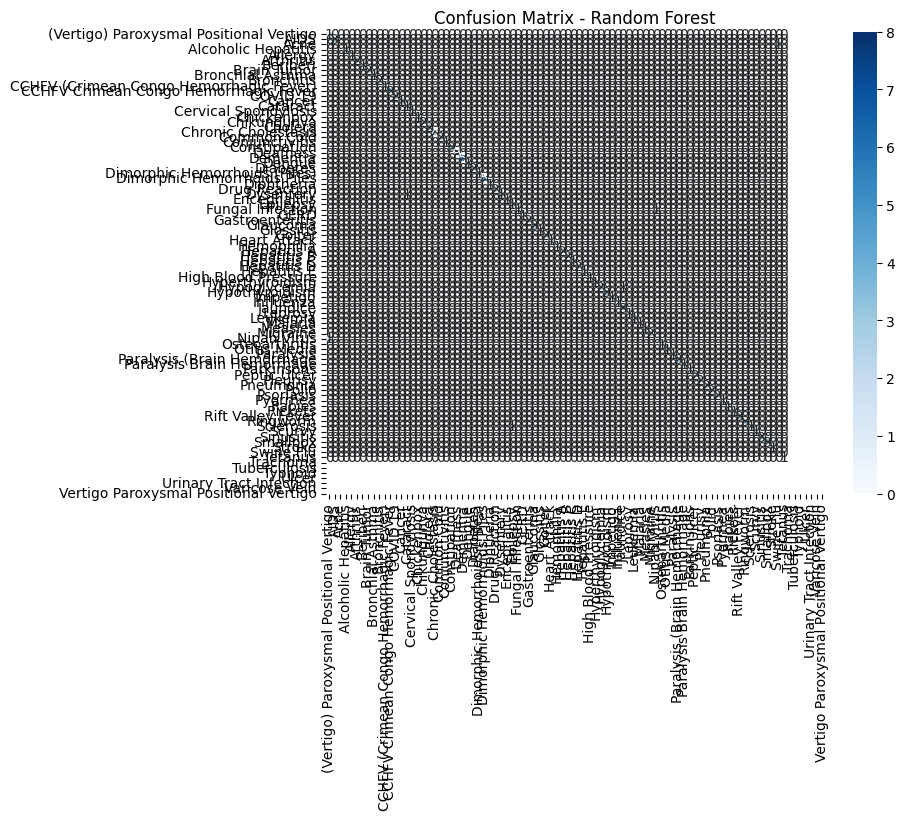

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

best_model_name = results_df.index[0]
best_model = best_models[best_model_name]
y_pred_best = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

# # Feature importance (tree-based)
# if hasattr(best_model.named_steps['model'], 'feature_importances_'):
#     feature_imp = pd.DataFrame({
#         'feature': X_selected.columns,
#         'importance': best_model.named_steps['model'].feature_importances_
#     }).sort_values('importance', ascending=False).head(15)
    
#     sns.barplot(data=feature_imp, x='importance', y='feature')
#     plt.title(f'Top 15 Features - {best_model_name}')
#     plt.show()


In [25]:
joblib.dump(best_model, f'best_model_{best_model_name.replace(" ","_").lower()}.pkl')
joblib.dump(le, 'label_encoder.pkl')
# joblib.dump(top_features_rf, 'selected_features.pkl')


['label_encoder.pkl']

In [27]:
def predict_disease(symptoms, model, label_encoder, feature_names, threshold=0.5):
    input_data = np.zeros(len(feature_names))
    for symptom in symptoms:
        if symptom in feature_names:
            idx = list(feature_names).index(symptom)
            input_data[idx] = 1
    input_data = input_data.reshape(1,-1)
    
    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(input_data)[0]
        prediction_idx = np.argmax(probabilities)
        confidence = probabilities[prediction_idx]
        if confidence < threshold:
            return "Uncertain - Low confidence", confidence
        else:
            return label_encoder.inverse_transform([prediction_idx])[0], confidence
    else:
        prediction_idx = model.predict(input_data)[0]
        return label_encoder.inverse_transform([prediction_idx])[0], 1.0




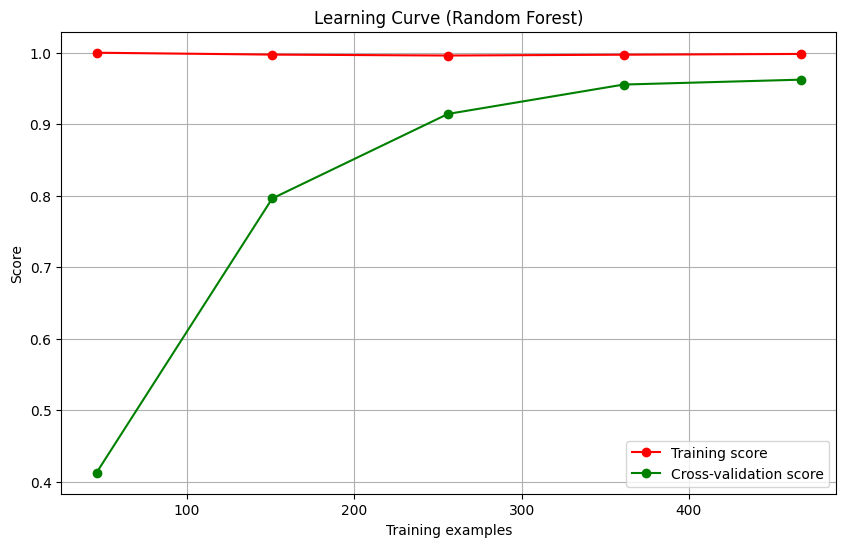

In [28]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=None):
    plt.figure(figsize=(10,6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv)
    plt.plot(train_sizes, np.mean(train_scores,axis=1), 'o-', color='r', label='Training score')
    plt.plot(train_sizes, np.mean(test_scores,axis=1), 'o-', color='g', label='Cross-validation score')
    plt.grid()
    plt.legend()
    plt.show()

plot_learning_curve(best_model, f"Learning Curve ({best_model_name})", X_train, y_train, cv=kfold)
